In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math 
#from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [2]:
from utils import *

## Iterative non linear dimensionality reduction using Manifold Sculping

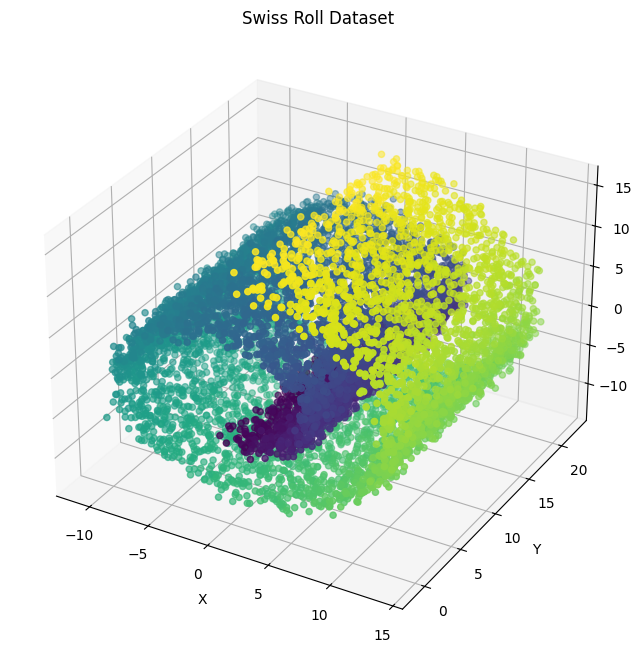

In [3]:
# Start by creating the swiss-role dataset 

# Generate Swiss roll dataset
n = 10000
noise = 0.5
X, color = make_swiss_roll(n_samples= n, noise= noise, random_state=42)

# Plot the Swiss roll
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.viridis)

ax.set_title('Swiss Roll Dataset')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()


In [4]:
## PARAMETERS 
k = 5     # number of neighbours
pca_dim = 2       # pca dimension
final_dim = 1     # number of target dimension into which the data will be projected
sigma = 0.99      # constant scaling factor between 0 and 1
eta = 0           # step size (dynamically adjusted)  


In [5]:
# Step 1 : find k nearest neighbours for each point -start with k=5
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
distances, indices = nbrs.kneighbors(X)
# distances contains the distance between each point and its k nearest neighbours
# indices contains the index of each point and the one of its k nearest neighbours 
indices[0,3] # it is the 3rd nearest neighbour of the first point

8878

In [7]:
#Step 2 : compute a set of relationships between neighbouring points
angle = []
most_colinear_neighbor = []
for i in range(n):
    for j in range(1, k+1):
        # compute the angle between the point and its k nearest neighbours
        most_colinear_neighbor.append(find_colinear_neighbor(X, i, indices[i,j], indices[i,1:]))  #si muove con i
        angle.append(compute_angle(X[i], X[indices[i,j]], X[most_colinear_neighbor[i]]))


average_dist = compute_distances(X, k, indices, n)
average_dist

0.12243766060956111

In [50]:
#dist[:5] # distance between the first point and its 5 nearest neighbours
#dist[5:10] # distance between the second point and its 5 nearest neighbours

[0.37223761294738833,
 0.46068423763739663,
 0.5253579448618957,
 0.5550141017379828,
 0.5570994039179806]

In [8]:
# Step 3 : Optionally align axes using PCA
X = PCA(n_components = pca_dim).fit_transform(X)

In [11]:
# Step 4 : Transform the data
for iter in range(int(math.log(0.01, sigma))):
    for i in range(n):
        for j in range(final_dim, X.shape[1]):
                X[i,j] = X[i,j]*sigma
    new_av_dist = compute_distances(X, k, indices, n)

    while new_av_dist < average_dist:
        for i in range(n):
            for j in range(final_dim):
                X[i,j] = X[i,j]/sigma
    new_av_dist = compute_distances(X, k, indices, n)
    
   #### not finished yet

KeyboardInterrupt: 